# Can we tell that "a fraction of genes is overexpressed"?

Companion to `dirichlet-multinomial-simulation.ipynb`. Same setup — counts from a
Dirichlet–multinomial with overdispersion $\theta$ and library sizes $N_s$ — but now the
question is an **identifiability** one. Suppose condition B arises from a generative
*absolute* process: some fraction $f$ of categories (genes/taxa) has its absolute
abundance multiplied by $D$. What can the observed counts $(y_s, N_s)$ actually tell us?

**TL;DR — three layers of identifiability**

| question | answer from counts alone | why |
|---|---|---|
| Did *anything* shift in composition? | ✅ yes (with overdispersion-aware tests) | compositions $\pi_g$ are identified by the data |
| Which categories shifted, by how much (composition units)? | ✅ yes | same |
| Is that shift due to **absolute overexpression** of those $f$ categories? | ❌ no | the **mirror** scenario — *complement* ×$1/D$ — produces **identical** compositions |
| Can the **total counts** $N$ break the mirror tie? | ⚠️ only under the assumption *reads ∝ molecules* | otherwise an $N$ shift is indistinguishable from a sequencing-rate change |
| Can we see a **global** ×$c$ overexpression of *everything*? | ⚠️ composition: no; $N$: yes, but then indistinguishable from "no change + deeper sequencing" | a global factor cancels in composition |
| Recover **absolute** fold changes? | ❌ not without an anchor | spike-ins / housekeeping genes / majority rule — all *assumptions*, and each can fail |

Roadmap: §1 absolute-abundance model + mirror construction → §2 the mirror experiment →
§3 the global-shift experiment → §4 what "detectable" costs (overdispersion & false positives) →
§5 anchors: what median-ratio normalization actually buys you.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from IPython.display import display

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20240614)

print("numpy", np.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)

numpy 2.5.3 | pandas 3.0.5 | seaborn 0.13.2


## 1. From compositions to an absolute story — and the mirror identity

Give categories base absolute abundances $a_i$ (proportions $\pi_i = a_i/\sum_j a_j$).
Condition B multiplies a subset $U$ (a fraction $f$ of categories) by an overexpression
factor $D$:

$$
\pi^{B}_i \;=\; \frac{\pi_i\,D^{\mathbb{1}[i\in U]}}{C},
\qquad C \;=\; \sum_i \pi_i\,D^{\mathbb{1}[i\in U]} \;=\; 1 + \mu\,(D-1),
$$

where $C$ is the **material multiplier** — the absolute pool of molecules grows by $C$
in B — and $\mu = \sum_{i\in U}\pi_i$ is the **abundance-weighted** mass of the
overexpressed set. (Weighting matters: choosing the *most abundant* 20% of categories
moves far more than 20% of the material.)

The **mirror** scenario multiplies the *complement* by $1/D$ (material multiplier
$(1-\mu) + \mu/D$). Renormalizing shows the two give *the same composition*:

$$
\frac{\pi_i/D}{(1-\mu) + \mu/D} \;=\; \frac{D\,\pi_i}{1 + \mu(D-1)} \qquad (i \in U).
$$

So "a fraction of genes overexpressed ×3" and "its complement underexpressed ×⅓" are
**observationally identical compositions**. The only quantities that could separate them
live outside the composition: the total-count distribution $N_s$ (and only if we treat
$N$ as a census of molecules), or an external anchor (§5).

I simulate with the DM sampler of the previous notebook ($\theta=100$, mild
overdispersion) under two depth regimes:

* **census** — reads ∝ molecules: $N_s \sim \operatorname{LogNormal}(\log(\bar N \cdot C_g), \sigma^2)$,
* **capped** — the sequencer always reaches the same depth: same law with $C_g = 1$ for both groups.

In [2]:
# ------------------------------------------------------------- helpers ----
D_EX = 3.0            # overexpression factor
K0 = 50               # categories
N_SAMPLES0 = 40       # per group
MED_N0, SIGMA_N0 = 20_000, 0.35
THETA0 = 100.0        # Dirichlet concentration (mild overdispersion)
COL_A, COL_B, COL_M = "#4C72B0", "#DD8452", "#55A868"


def make_pi(K, rng, sigma=1.2, sort_descending=True):
    # base absolute abundances ~ lognormal
    a = rng.lognormal(0.0, sigma, K)
    if sort_descending:
        a = np.sort(a)[::-1]
    return a / a.sum()


def fold_pi(pi, mask, factor):
    # multiply masked categories' absolute abundance by `factor`, renormalize
    # returns (composition, material multiplier)
    m = np.ones(len(pi))
    m[mask] = factor
    pi2 = pi * m
    return pi2 / pi2.sum(), float(pi2.sum())


def simulate_group(pi, theta, n, census_factor=1.0, med_n=20_000, sigma_n=0.35, rng=None):
    # census_factor scales the library-size law proportionally (census regime);
    # census_factor = 1 for both groups models a sequencer-capped, equal-depth design,
    # in which case N carries no information about absolute material
    P = np.vstack([rng.dirichlet(theta * pi) for _ in range(n)])
    N = np.round(rng.lognormal(np.log(med_n * census_factor), sigma_n, n)).astype(int)
    counts = np.vstack([rng.multinomial(N[t], P[t]) for t in range(n)])
    return counts, N


def mean_proportion(counts, N):
    return (counts / N[:, None]).mean(axis=0)


def log2fc(mean_b, mean_a):
    return np.log2(mean_b / mean_a)


def fc_replicates(pi_b, pi_a, census_b, R=150, n=40, theta=THETA0, rng=None, med_n_b=None):
    # repeat the two-group experiment R times; returns per-gene log2FC of
    # mean observed proportions (B / A), one row per replicate.
    # med_n_b overrides the library-size law of the B group (e.g. deeper sequencing)
    med_b = MED_N0 if med_n_b is None else med_n_b
    out = np.empty((R, len(pi_a)))
    for r in range(R):
        cnt_a, N_a = simulate_group(pi_a, theta, n, 1.0, MED_N0, SIGMA_N0, rng)
        cnt_b, N_b = simulate_group(pi_b, theta, n, census_b, med_b, SIGMA_N0, rng)
        out[r] = log2fc(mean_proportion(cnt_b, N_b), mean_proportion(cnt_a, N_a))
    return out


def plot_band(ax, reps, col, label):
    med = np.median(reps, axis=0)
    q1, q3 = np.percentile(reps, [25, 75], axis=0)
    x = np.arange(reps.shape[1])
    ax.fill_between(x, q1, q3, color=col, alpha=0.22, lw=0)
    ax.plot(x, med, color=col, lw=1.8, label=label)


def N_sample(pi, census, n=400, med_n=MED_N0):
    _, N = simulate_group(pi, THETA0, n, census, med_n, SIGMA_N0, rng)
    return N

## 2. The mirror experiment: f ×D vs (1−f) ×1/D

Two completely different *absolute* stories. Each replicate redraws 40 fresh samples per
group; panels show the median per-gene log2FC with the interquartile band, and the
library-size distributions from 400-sample draws.

mass of overexpressed set: mu = 0.533 (f = 0.2 of categories)
material multiplier: T1 = 2.0650 | mirror = 0.6883 (ratio 3.00)
mirror identity: compositions of T1 and T2 identical -> True


CENSUS regime verdict: compositions identical; N differs by factor 3.1 — separable, but ONLY because we chose to read N as molecules.


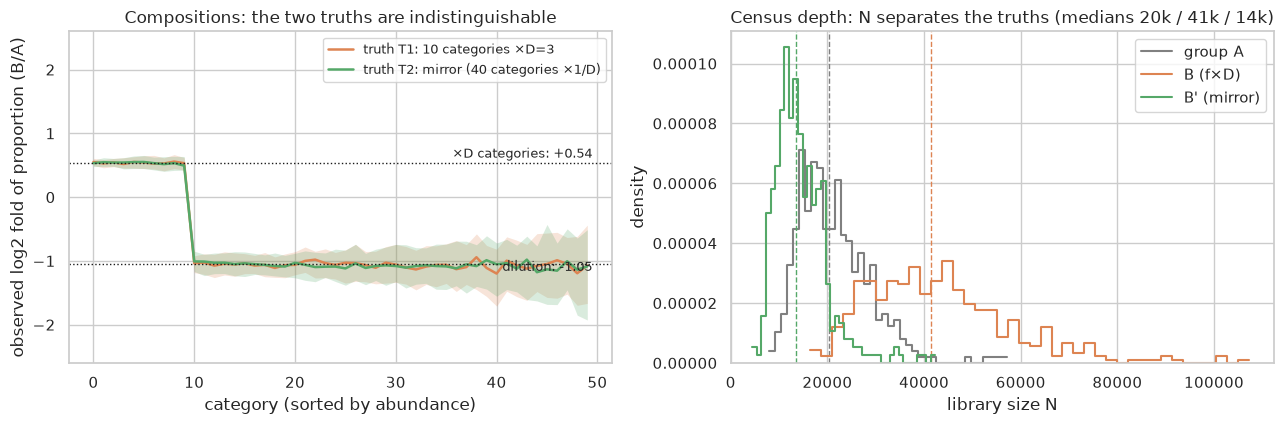

In [3]:
pi0 = make_pi(K0, rng)
f = 0.2
n_up = int(round(f * K0))
UP = np.arange(n_up)                       # overexpressed: the 10 most abundant categories
W = ~np.isin(np.arange(K0), UP)

piT1, C1 = fold_pi(pi0, UP, D_EX)          # T1: 10 categories ×3       -> material × C1
piT2, C2 = fold_pi(pi0, W, 1.0 / D_EX)     # T2 mirror: 40 categories ×1/3 -> material × C2
mu = float(pi0[UP].sum())
print(f"mass of overexpressed set: mu = {mu:.3f} (f = {f} of categories)")
print(f"material multiplier: T1 = {C1:.4f} | mirror = {C2:.4f} (ratio {C1 / C2:.2f})")
print("mirror identity: compositions of T1 and T2 identical ->", np.allclose(piT1, piT2, atol=1e-12))

# Census regime -----------------------------------------------------------------
reps_T1 = fc_replicates(piT1, pi0, C1, rng=rng)
reps_T2 = fc_replicates(piT2, pi0, C2, rng=rng)

N_A_big, N_T1_big, N_T2_big = N_sample(pi0, 1.0), N_sample(piT1, C1), N_sample(piT2, C2)

expected_up = np.log2(D_EX / C1)           # expected composition fold for overexpressed
expected_w = -np.log2(C1)                  # expected dilution elsewhere

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

ax = axes[0]
plot_band(ax, reps_T1, COL_B, "truth T1: 10 categories ×D=3")
plot_band(ax, reps_T2, COL_M, "truth T2: mirror (40 categories ×1/D)")
ax.axhline(expected_up, color="k", ls=":", lw=1)
ax.axhline(expected_w, color="k", ls=":", lw=1)
ax.text(K0 - 0.5, expected_up + 0.08, f"×D categories: {expected_up:+.2f}", ha="right", fontsize=9)
ax.text(K0 - 0.5, expected_w - 0.11, f"dilution: {expected_w:+.2f}", ha="right", fontsize=9)
ax.set(xlabel="category (sorted by abundance)", ylim=(-2.6, 2.6),
       ylabel="observed log2 fold of proportion (B/A)",
       title="Compositions: the two truths are indistinguishable")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
for lbl, Ns, col in [("group A", N_A_big, "0.5"), ("B (f×D)", N_T1_big, COL_B),
                     ("B' (mirror)", N_T2_big, COL_M)]:
    sns.histplot(x=Ns, bins=40, stat="density", element="step", fill=False,
                 color=col, label=lbl, ax=ax)
    ax.axvline(np.median(Ns), color=col, ls="--", lw=1)
ax.set(xlabel="library size N", ylabel="density", xlim=(0, None),
       title="Census depth: N separates the truths (medians "
             f"{np.median(N_A_big)/1e3:.0f}k / {np.median(N_T1_big)/1e3:.0f}k / "
             f"{np.median(N_T2_big)/1e3:.0f}k)")
ax.legend()

fig.tight_layout()
print("CENSUS regime verdict: compositions identical; N differs by factor "
      f"{np.median(N_T1_big) / np.median(N_T2_big):.1f} — separable, but ONLY because "
      "we chose to read N as molecules.")

max |median log2FC difference| between the two truths (20 most abundant categories): 0.056 — pure sampling noise
CAPPED regime verdict: '10 categories ×3', '40 categories ×1/3' — indistinguishable,
both still distinguishable from 'no change' (their composition moved); direction (up vs down) is not.


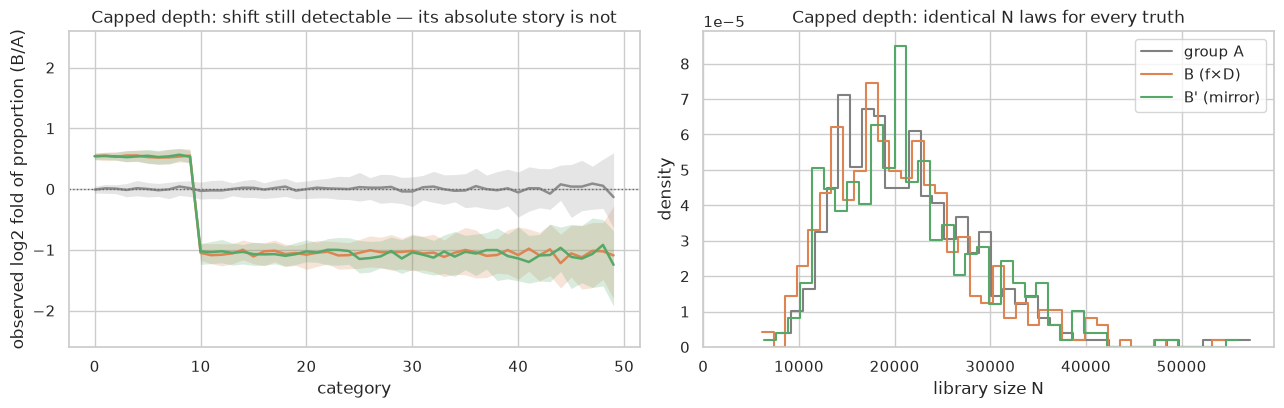

In [4]:
# Capped-depth regime: the sequencer always reaches the same total count
reps_T1c = fc_replicates(piT1, pi0, 1.0, rng=rng)
reps_T2c = fc_replicates(piT2, pi0, 1.0, rng=rng)
reps_null = fc_replicates(pi0, pi0, 1.0, rng=rng)          # truth: no change at all

N_B1c, N_B2c = N_sample(piT1, 1.0), N_sample(piT2, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

ax = axes[0]
plot_band(ax, reps_T1c, COL_B, "truth T1: 10 ×D=3")
plot_band(ax, reps_T2c, COL_M, "truth T2: mirror ×1/D")
plot_band(ax, reps_null, "0.55", "truth: no change")
ax.axhline(0, color="0.4", ls=":", lw=1)
ax.set(xlabel="category", ylim=(-2.6, 2.6),
       ylabel="observed log2 fold of proportion (B/A)",
       title="Capped depth: shift still detectable — its absolute story is not")

ax = axes[1]
for lbl, Ns, col in [("group A", N_A_big, "0.5"), ("B (f×D)", N_B1c, COL_B),
                     ("B' (mirror)", N_B2c, COL_M)]:
    sns.histplot(x=Ns, bins=40, stat="density", element="step", fill=False,
                 color=col, label=lbl, ax=ax)
ax.set(xlabel="library size N", ylabel="density", xlim=(0, None),
       title="Capped depth: identical N laws for every truth")
ax.legend()

fig.tight_layout()

sep = np.abs(np.median(reps_T1c, axis=0) - np.median(reps_T2c, axis=0))[:20].max()
print(f"max |median log2FC difference| between the two truths "
      f"(20 most abundant categories): {sep:.3f} — pure sampling noise")
print("CAPPED regime verdict: '10 categories ×3', '40 categories ×1/3' — indistinguishable,")
print("both still distinguishable from 'no change' (their composition moved); direction (up vs down) is not.")

## 3. The global-shift experiment: overexpression of *everything*

If condition B scales **all** categories by $c=2$, the composition does not move — a uniform
factor cancels in $\pi$. Three stories:

* **G1** — global ×2 overexpression, census depth,
* **G2** — *no* expression change, but a deeper sequencer (depth ×2),
* **G3** — global ×2 overexpression, capped depth.

max |median log2FC| across the 20 most abundant categories and all truths: 0.065 (≈ 0 within noise)
median N: A 20k | G1 40k | G2 41k | G3 20k
-> global overexpression is invisible in composition, and N cannot say WHY it moved.


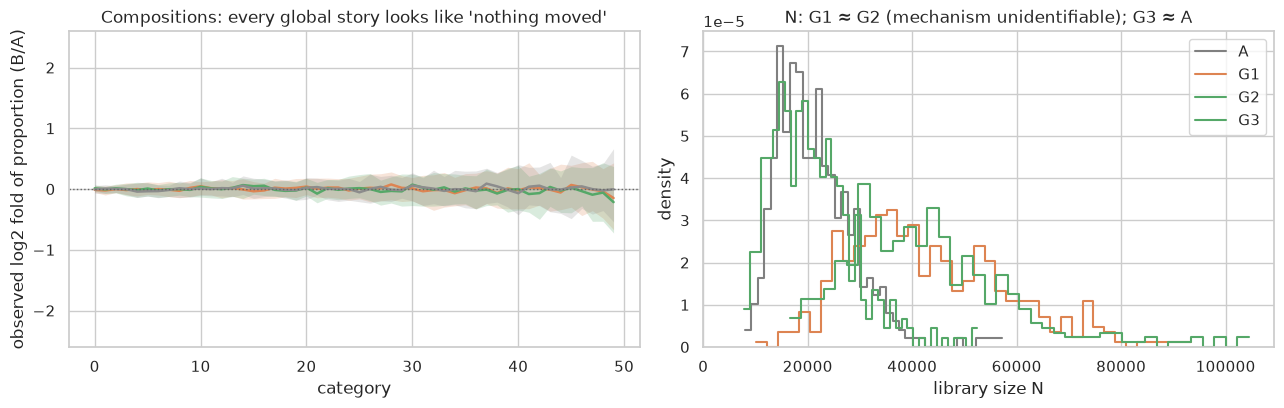

In [5]:
piG, CG = fold_pi(pi0, np.ones(K0, dtype=bool), 2.0)

reps_G1 = fc_replicates(piG, pi0, CG, R=120, rng=rng)
reps_G2 = fc_replicates(pi0, pi0, 1.0, R=120, rng=rng, med_n_b=MED_N0 * 2)   # twice as deep
reps_G3 = fc_replicates(piG, pi0, 1.0, R=120, rng=rng)

N_G1, N_G2, N_G3 = N_sample(piG, CG), N_sample(pi0, 1.0, med_n=40000), N_sample(piG, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

ax = axes[0]
plot_band(ax, reps_G1, COL_B, "G1: global ×2, census")
plot_band(ax, reps_G3, COL_M, "G3: global ×2, capped")
plot_band(ax, reps_G2, "0.55", "G2: no change, deeper seq")
ax.axhline(0, color="0.4", ls=":", lw=1)
ax.set(xlabel="category", ylim=(-2.6, 2.6),
       ylabel="observed log2 fold of proportion (B/A)",
       title="Compositions: every global story looks like 'nothing moved'")

ax = axes[1]
for lbl, Ns, col in [("A", N_A_big, "0.5"), ("G1", N_G1, COL_B),
                     ("G2", N_G2, COL_M), ("G3", N_G3, COL_M)]:
    sns.histplot(x=Ns, bins=40, stat="density", element="step", fill=False,
                 color=col, label=lbl, ax=ax)
ax.set(xlabel="library size N", ylabel="density", xlim=(0, None),
       title="N: G1 ≈ G2 (mechanism unidentifiable); G3 ≈ A")
ax.legend()

fig.tight_layout()

mx = max(np.abs(np.median(r, axis=0))[:20].max() for r in (reps_G1, reps_G2, reps_G3))
print(f"max |median log2FC| across the 20 most abundant categories and all truths: "
      f"{mx:.3f} (≈ 0 within noise)")
print(f"median N: A {np.median(N_A_big)/1e3:.0f}k | G1 {np.median(N_G1)/1e3:.0f}k "
      f"| G2 {np.median(N_G2)/1e3:.0f}k | G3 {np.median(N_G3)/1e3:.0f}k")
print("-> global overexpression is invisible in composition, and N cannot say WHY it moved.")

## 4. What "detectable" costs: overdispersion and false positives

Even the *identifiable* part — enumerating which categories' compositions shifted —
requires variance that respects the Dirichlet overdispersion $\theta$. The naive
multinomial variance underestimates the true variance by the factor
$\frac{N+\theta}{1+\theta}$ $\;(\approx 400$ with $N=20{,}000$, $\theta=50)$, so *every*
category looks differentially abundant.

Monte-Carlo null: two groups with **identical** compositions, $n=30$ per group,
$K=100$ categories, lognormal depths, two-sided $z$ tests at $\alpha = 0.05$ on the
difference of mean observed proportions — one with naive multinomial variance, one with
the Dirichlet–multinomial variance (oracle $\theta$; in practice $\theta$ is estimated,
e.g. by beta-binomial or Dirichlet-multinomial regression).

FPR by theta (naive): ['0.25', '0.75', '0.89', '0.92', '0.94']
FPR by theta (DM):    ['0.05', '0.05', '0.04', '0.04', '0.03']
-> with the DM variance the test is calibrated (≈5%), so the *set* of shifted
   categories can be enumerated; with the naive variance every gene 'shifts'.


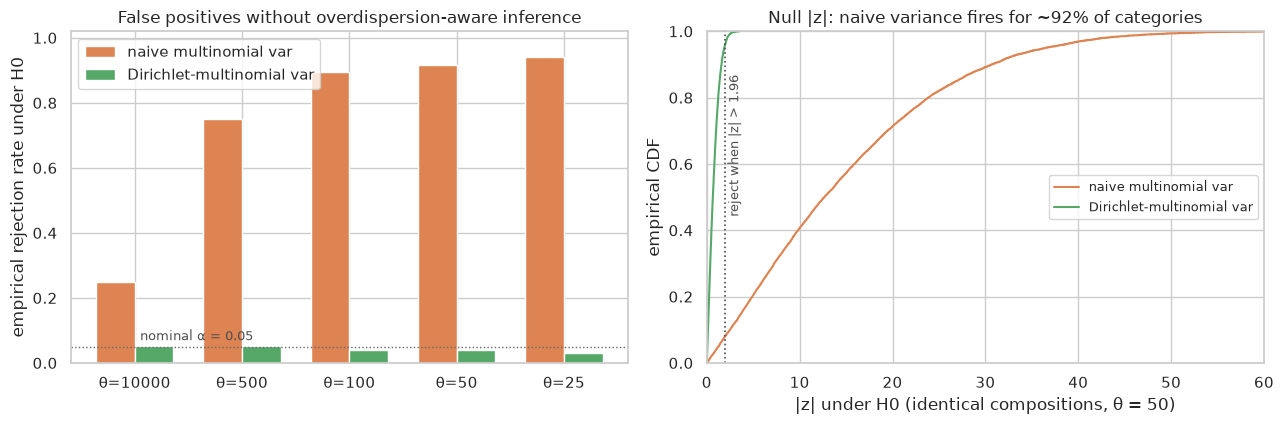

In [6]:
def collect_z(theta, K=100, n=30, R=60, med_n=20_000, sigma_n=0.3, rng=None,
              pi_fixed=None, shift_mask=None, shift_factor=1.0):
    # returns per-gene z-scores for (naive, DM) variance under repeated experiments;
    # pass pi_fixed/shift_mask to simulate a known truth instead of the null
    out = np.empty((R, K, 2))
    for r in range(R):
        pi = pi_fixed if pi_fixed is not None \
            else make_pi(K, rng, sigma=1.2, sort_descending=False)
        piB = pi if shift_mask is None else fold_pi(pi, shift_mask, shift_factor)[0]
        cntA, NA_ = simulate_group(pi, theta, n, 1.0, med_n, sigma_n, rng)
        cntB, NB_ = simulate_group(piB, theta, n, 1.0, med_n, sigma_n, rng)

        pooled = (cntA.sum(0) + cntB.sum(0)) / (NA_.sum() + NB_.sum())
        p01 = pooled * (1.0 - pooled)
        with np.errstate(divide="ignore", invalid="ignore"):
            v_naive = p01 * (np.mean(1.0 / NA_) + np.mean(1.0 / NB_))
            v_dm = p01 * (np.mean((NA_ + theta) / (NA_ * (1.0 + theta)))
                          + np.mean((NB_ + theta) / (NB_ * (1.0 + theta))))

        xA = (cntA / NA_[:, None]).mean(0)
        xB = (cntB / NB_[:, None]).mean(0)
        # Var(x̄A − x̄B) = p(1−p) · [E_A(1/N) + E_B(1/N)] / n   (naive: multinomial)
        #                = p(1−p) · [E_A((N+θ)/(N(1+θ))) + E_B((N+θ)/(N(1+θ)))] / n   (DM)
        se = 1.0 / np.sqrt(n)
        den_naive = np.where(v_naive > 0, np.sqrt(v_naive), np.inf) * se
        den_dm = np.where(v_dm > 0, np.sqrt(v_dm), np.inf) * se
        z_naive = (xB - xA) / den_naive
        z_dm = (xB - xA) / den_dm
        out[r, :, 0], out[r, :, 1] = z_naive, z_dm
    return out[..., 0].ravel(), out[..., 1].ravel()


theta_grid = [10_000.0, 500.0, 100.0, 50.0, 25.0]
fpr = {m: [] for m in ("naive", "dm")}
for th in theta_grid:
    z_naive, z_dm = collect_z(th, rng=rng)
    fpr["naive"].append(float(np.mean(np.abs(z_naive) > 1.96)))
    fpr["dm"].append(float(np.mean(np.abs(z_dm) > 1.96)))

z_naive_50, z_dm_50 = collect_z(50.0, R=100, rng=rng)       # for the null z histogram

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

ax = axes[0]
xx = np.arange(len(theta_grid))
ax.bar(xx - 0.18, fpr["naive"], width=0.36, color=COL_B, label="naive multinomial var")
ax.bar(xx + 0.18, fpr["dm"], width=0.36, color=COL_M, label="Dirichlet-multinomial var")
ax.axhline(0.05, color="0.4", ls=":", lw=1)
ax.text(0.05, 0.07, "nominal α = 0.05", fontsize=9, color="0.3")
ax.set(xticks=xx, xticklabels=[f"θ={th:g}" for th in theta_grid],
       ylim=(0, 1.02), ylabel="empirical rejection rate under H0",
       title="False positives without overdispersion-aware inference")
ax.legend()

ax = axes[1]
sns.ecdfplot(x=np.abs(z_naive_50), color=COL_B, label="naive multinomial var", ax=ax)
sns.ecdfplot(x=np.abs(z_dm_50), color=COL_M, label="Dirichlet-multinomial var", ax=ax)
ax.axvline(1.96, color="0.3", ls=":", lw=1.2)
ax.text(2.2, 0.45, "reject when |z| > 1.96", fontsize=9, color="0.3", rotation=90)
ax.set(xlabel="|z| under H0 (identical compositions, θ = 50)", xlim=(0, 60),
       ylabel="empirical CDF",
       title="Null |z|: naive variance fires for ~92% of categories")
ax.legend(loc="center right", fontsize=9)

fig.tight_layout()

print("FPR by theta (naive):", [f"{v:.2f}" for v in fpr["naive"]])
print("FPR by theta (DM):   ", [f"{v:.2f}" for v in fpr["dm"]])
print("-> with the DM variance the test is calibrated (≈5%), so the *set* of shifted")
print("   categories can be enumerated; with the naive variance every gene 'shifts'.")

## 5. Anchors — what normalization actually buys (and when it breaks)

An **anchor** is a set of categories declared *unchanged* in absolute terms; all estimates
become anchor-relative statements. Standard choices: external **spike-ins** (genuinely
identify absolutes), **housekeeping genes**, or the **majority rule** — "most categories
are unchanged" — which is what median-of-ratios (DESeq2) and TMM *assume*.

Median-of-ratios size factors $s_s = \mathrm{median}_i\,(y_{si}+0.5)/g_i$, with $g_i$ the
geometric mean of gene $i$ across samples, pick the scale up from the *median* category:

* if $f \ll 0.5$, the median category is unchanged and the estimates land back on the
  true absolute expression factors $m_i$ (overexpressed → $D$, others → 1);
* if $f \gtrsim 0.5$, the *median category is itself overexpressed*: the anchor absorbs
  part of the effect and **every** estimate is scaled down by it. Mechanistically, the
  per-gene ratio to the all-sample geometric mean gains a $\sqrt{m_i}$ for shifted genes
  (half the samples carry ×$m_i$), so when the median gene is shifted the size factor
  inflates by ≈ $\sqrt{D}$ and estimates land at ≈ $m_i/\sqrt{D}$ — the overexpressed
  genes compress below their truth and the unchanged genes gain a spurious dilution.

This is the mechanism behind `median-of-ratios-normalization-breaks.ipynb`, now in an
explicit DM setting (census depth; low-expression genes with geometric mean < 5 counts are
excluded, as DESeq2-style pipelines do).

f = 0.2: (75/200 genes expressible)
   overexpressed: median estimated +1.43 (true +1.58)   |   unchanged: median estimated -0.17 (true 0.00)
f = 0.6: (91/200 genes expressible)
   overexpressed: median estimated +0.72 (true +1.58)   |   unchanged: median estimated -0.94 (true 0.00)
-> f < 0.5: estimates land close to the absolute truth (anchor holds).
-> f > 0.5: the anchor absorbs ~sqrt(D) and every estimate is biased downward;
   unchanged genes appear underexpressed, overexpressed genes shrink toward 0.


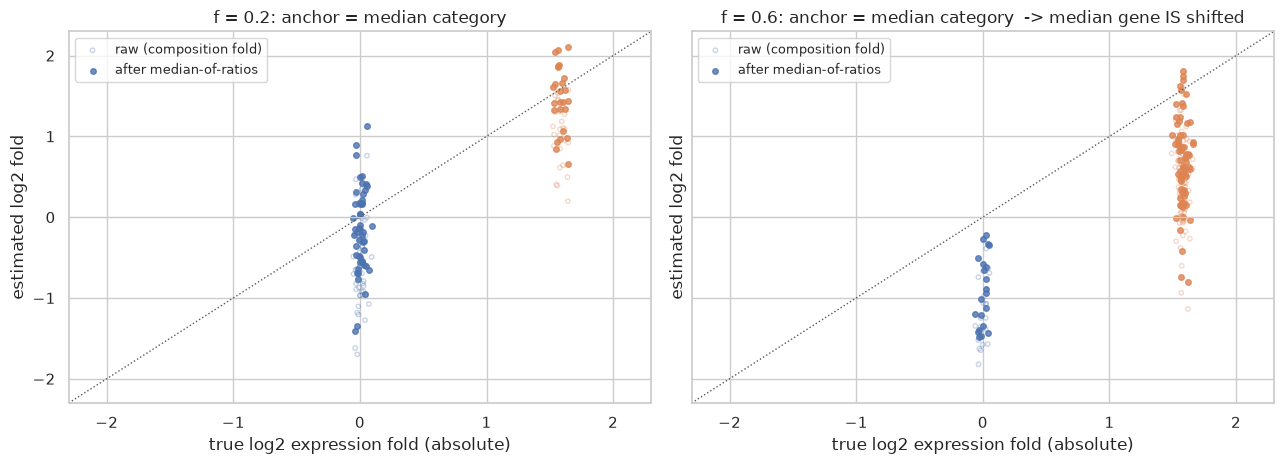

In [7]:
def median_ratio_size_factors(counts):
    # DESeq2-style size factors with the standard pseudocount
    c = counts + 0.5
    geo = np.exp(np.log(c).mean(axis=0))
    return np.median(c / geo, axis=1)


def anchor_experiment(frac, D=3.0, theta=100.0, n=30, K=200, rng=None,
                      med_n=50_000, sigma_ab=1.0):
    pi = make_pi(K, rng, sigma=sigma_ab, sort_descending=False)
    mask = np.zeros(K, dtype=bool)
    mask[rng.choice(K, int(round(frac * K)), replace=False)] = True
    m = np.where(mask, D, 1.0)
    C = float((pi * m).sum())
    cntA, NA_ = simulate_group(pi, theta, n, 1.0, med_n, 0.35, rng)
    cntB, NB_ = simulate_group(pi * m / C, theta, n, C, med_n, 0.35, rng)

    base = np.vstack([cntA, cntB]).astype(float)
    g = np.exp(np.log(np.clip(base, 1e-12, None)).mean(axis=0))  # ~geomean of raw counts
    keep = g >= 5.0                                              # expressible genes only

    sf = median_ratio_size_factors(base)
    normed = base / sf[:, None]
    est = np.log2(normed[n:].mean(0) / normed[:n].mean(0))
    raw = np.log2((cntB / NB_[:, None]).mean(0) / (cntA / NA_[:, None]).mean(0))
    return raw, est, np.where(mask, np.log2(D), 0.0), mask, C, keep


fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharey=True)
results = {}
for ax, frac in zip(axes, [0.2, 0.6]):
    raw, est, true_log2, mask, C, keep = anchor_experiment(frac, rng=rng)
    results[frac] = (est, true_log2, mask, keep)
    jitter = rng.normal(0.0, 0.03, keep.sum())
    tx = true_log2[keep]
    ax.scatter(tx[~mask[keep]] + jitter[~mask[keep]], raw[keep][~mask[keep]], s=10,
               alpha=0.3, facecolors="none", edgecolors=COL_A, label="raw (composition fold)")
    ax.scatter(tx[mask[keep]] + jitter[mask[keep]], raw[keep][mask[keep]], s=10,
               alpha=0.3, facecolors="none", edgecolors=COL_B)
    ax.scatter(tx[~mask[keep]] + jitter[~mask[keep]], est[keep][~mask[keep]], s=16,
               alpha=0.8, color=COL_A, label="after median-of-ratios")
    ax.scatter(tx[mask[keep]] + jitter[mask[keep]], est[keep][mask[keep]], s=16,
               alpha=0.8, color=COL_B)
    lo, hi = -2.3, 2.3
    ax.plot([lo, hi], [lo, hi], color="0.35", ls=":", lw=1, zorder=1)
    ax.axhline(0, color="0.8", lw=0.8)
    ax.set(xlim=(lo, hi), ylim=(lo, hi), xlabel="true log2 expression fold (absolute)",
           ylabel="estimated log2 fold",
           title=f"f = {frac:g}: anchor = median category"
                 + ("  -> median gene IS shifted" if frac > 0.5 else ""))
    ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()

for frac in [0.2, 0.6]:
    est, true_log2, mask, keep = results[frac]
    up = mask & keep
    un = (~mask) & keep
    print(f"f = {frac}: ({keep.sum()}/{len(mask)} genes expressible)")
    print(f"   overexpressed: median estimated {np.median(est[up]):+.2f} "
          f"(true {np.median(true_log2[up]):+.2f})"
          f"   |   unchanged: median estimated {np.median(est[un]):+.2f} "
          f"(true {np.median(true_log2[un]):.2f})")
print("-> f < 0.5: estimates land close to the absolute truth (anchor holds).")
print("-> f > 0.5: the anchor absorbs ~sqrt(D) and every estimate is biased downward;")
print("   unchanged genes appear underexpressed, overexpressed genes shrink toward 0.")

## Distinguishability matrix

| truth pair | compositions | library sizes | separable by |
|---|---|---|---|
| $f$ categories ×$D$ vs complement ×$1/D$ (census) | identical | differ (×$D$ material ratio) | $N$ — *if* read as molecules |
| $f$ categories ×$D$ vs complement ×$1/D$ (capped) | identical | identical | ** nothing in the counts |
| global ×$c$ vs no change + deeper sequencing (census) | identical | identical | ** nothing in the counts |
| global ×$c$ (capped) vs no change | identical | identical | ** nothing in the counts |
| $f$ categories shifted vs no shift | differ | — | θ-aware tests (naive tests call *everything* shifted) |
| absolute interpretation (up vs down, or molecules) | — | — | spike-ins, housekeeping sets, majority rule — each an assumption |

## Conclusions

1. **Composition is scale-free.** DM data identify the per-group compositions $\pi_g$
   (and overdispersion $\theta$) — so *which* categories' proportions shifted is
   recoverable, with θ-aware inference (§4: naive variance → ~100% false positives;
   DM variance → calibrated ≈5%).
2. **"Overexpressed" is an absolute claim.** The same composition shift is produced by
   overexpression of the shifted set *or* underexpression of its complement (mirror
   identity, §2). Without extra assumptions the absolute story is not in the data.
3. **$N$ is only a bridge under a census assumption.** Reads ∝ molecules makes $N$
   informative about material, which breaks the mirror tie (§2) — but a global scaling
   factor then looks exactly like deeper sequencing (§3), so even that bridge needs an
   external calibration to separate "material grew" from "sampling rate grew".
4. **Anchors make it identifiable — conditionally.** Spike-ins identify absolutes;
   housekeeping/majority-rule anchors identify *anchor-relative* fold changes, and they
   break exactly when their assumption fails (§5; `median-of-ratios-normalization-breaks.ipynb`).
5. **Practical upshot:** to claim "a fraction of genes is overexpressed" from DM data,
   fix identifiability *by design* (spike-ins / controlled sampling) or state your anchor
   explicitly; estimate the shifted set with overdispersion-aware tests; and remember the
   result is a statement *relative to the anchor*, not about molecules.